# Notebook 08 - VolNetX Model Explainability

This notebook provides explainability analysis for the **VolNetX** volatility forecasting model.

We apply two complementary techniques that respect the model's architecture:

1. **Feature Sensitivity (Bump Test)**  
   For each input feature, we apply a controlled perturbation (±5%) across the 65-day lookback window and measure how the model's forecasts change for 1-day, 5-day, and 10-day horizons.  
   This answers: *"Which features actually move the forecast when the world changes?"*

2. **Temporal Attention Heatmap**  
   We visualize which days in the 65-day window the model's transformer layer attends to most strongly.  
   This answers: *"Which specific past days mattered most for this ticker today?"*

---

## Why NOT SHAP / Integrated Gradients?

Based on the explainability feasibility audit, these classical attribution methods are **incompatible** with VolNetX:

**Model Architecture** (what breaks traditional methods):
- **Two-headed input**: Time series window + categorical ticker embedding  
- **Feature dropout**: Stochastic channel masking during training  
- **Feature gating**: Learned multiplicative attention per feature  
- **LSTM backbone**: Temporal dependencies over 65-day sequences  
- **Transformer encoder**: Multi-head self-attention over hidden states  
- **Separate horizon heads**: Three independent nonlinear decoders + residual highway

**Why SHAP fails**:
- Cannot factor frozen ticker embedding vs. temporal feature window
- Treats 65×16 = 1,040 "features" as independent (violates temporal structure)
- Feature dropout breaks determinism assumption
- Feature gating creates non-additive interactions

**Why Integrated Gradients fails**:
- Cannot interpolate categorical ticker IDs across ℝ  
- No meaningful "baseline" for log-volatility time series  
- Freezing ticker ID breaks path integral completeness → NaN attributions

**Our solution**:  
Instead of forcing incompatible tools, we use **causal sensitivity analysis** (bump test) and **model-native explanations** (transformer attention weights).

---

## Imports and Setup

In [5]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from volsense_inference.model_loader import load_model
from volsense_core.utils.scalers import TorchStandardScaler

# Plot aesthetics
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DEVICE = "cpu"

## Load VolNetX Model + Data

We load the trained VolNetX model and the v2 dataset with macro/earnings features.

In [6]:
# Load model
model, meta, scalers, ticker_to_idx, features = load_model(
    'volnetx',
    checkpoints_dir='../models'
)

model.eval()
model.to(DEVICE)

# Load master dataset v2
full_df = pd.read_csv("../data/processed/master_lstm_dataset_v2.csv")

# Model config
WINDOW = 65
HORIZONS = meta.get("horizons", [1, 5, 10])
FEATURES = features

print("Loaded VolNetX model")
print(f" - Window: {WINDOW}")
print(f" - Horizons: {HORIZONS}")
print(f" - Features ({len(FEATURES)}): {FEATURES[:5]}... (showing first 5)")
print(f" - Tickers: {len(ticker_to_idx)}")

Loaded VolNetX model
 - Window: 65
 - Horizons: [1, 5, 10]
 - Features (23): ['return', 'vol_10d', 'vol_20d', 'vol_60d', 'vol_3d']... (showing first 5)
 - Tickers: 507


## Helper Functions

In [7]:
def prepare_ticker_window(ticker: str, df: pd.DataFrame, features: list, 
                          scalers: dict, ticker_to_idx: dict, window: int):
    """
    Prepare a single ticker's most recent window for inference.
    Uses PER-TICKER scaling as done during training.
    """
    # Extract ticker subset
    df_ticker = df[df["ticker"] == ticker].sort_values("date").copy()
    if len(df_ticker) < window:
        raise ValueError(f"{ticker} has insufficient history ({len(df_ticker)}) for window={window}")
    
    # Take last window
    df_ticker = df_ticker.tail(window)
    
    # Get features
    X_raw = df_ticker[features].fillna(0.0).values.astype(np.float32)
    
    # Apply per-ticker scaler
    if ticker in scalers:
        scaler = scalers[ticker]
        X_tensor = torch.tensor(X_raw)
        X_scaled_result = scaler.transform(X_tensor)
        # Handle both tensor and numpy array returns
        X_scaled = X_scaled_result.numpy() if torch.is_tensor(X_scaled_result) else X_scaled_result
    else:
        # Fallback to on-the-fly normalization if ticker not in scalers
        scaler_temp = TorchStandardScaler()
        X_tensor = torch.tensor(X_raw)
        scaler_temp.fit(X_tensor)
        X_scaled_result = scaler_temp.transform(X_tensor)
        X_scaled = X_scaled_result.numpy() if torch.is_tensor(X_scaled_result) else X_scaled_result
    
    # Convert to tensors
    x_input = torch.tensor(X_scaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    # Ticker index
    tidx = ticker_to_idx.get(ticker, 0)
    tidx_tensor = torch.tensor([tidx], dtype=torch.long).to(DEVICE)
    
    return x_input, tidx_tensor, features


@torch.no_grad()
def predict_all_horizons(model, tidx, x_input):
    """Run model inference and return predictions for all horizons."""
    model.eval()
    out = model(tidx, x_input)
    return out.squeeze(0).cpu().numpy()

## Select Example Ticker

We'll use **AAPL** for demonstration.

In [29]:
TICKER = "SPY"

x_input, tidx_tensor, feature_names = prepare_ticker_window(
    TICKER, full_df, FEATURES, scalers, ticker_to_idx, WINDOW
)

print(f"Prepared {TICKER}:")
print(f" - x_input shape: {x_input.shape}  (batch, window, features)")
print(f" - tidx: {tidx_tensor.item()}")
print(f" - Features: {len(feature_names)}")

Prepared SPY:
 - x_input shape: torch.Size([1, 65, 23])  (batch, window, features)
 - tidx: 407
 - Features: 23


## Baseline Prediction

In [30]:
baseline_pred = predict_all_horizons(model, tidx_tensor, x_input)

print(f"Baseline predictions for {TICKER}:")
for i, h in enumerate(HORIZONS):
    print(f"  {h}-day forecast (log-vol): {baseline_pred[i]:.4f}")

Baseline predictions for SPY:
  1-day forecast (log-vol): -1.9193
  5-day forecast (log-vol): -1.8543
  10-day forecast (log-vol): -2.2455


## Feature Sensitivity (Bump Test)

For each feature, we perturb it by ±5% across the entire window and measure the change in forecasts.

In [31]:
def bump_test(model, x_input, tidx, feature_names, horizons, eps=0.05):
    """
    Perturb each feature by ±eps and measure forecast sensitivity.
    
    Returns:
        sensitivity: dict[feature_name] -> dict[horizon] -> delta
    """
    base_pred = predict_all_horizons(model, tidx, x_input)
    sensitivity = {}
    
    for feat_i, fname in enumerate(feature_names):
        # Perturb +eps
        x_plus = x_input.clone()
        x_plus[:, :, feat_i] += eps
        
        # Perturb -eps
        x_minus = x_input.clone()
        x_minus[:, :, feat_i] -= eps
        
        pred_plus = predict_all_horizons(model, tidx, x_plus)
        pred_minus = predict_all_horizons(model, tidx, x_minus)
        
        # Symmetric difference derivative
        delta = (pred_plus - pred_minus) / 2.0
        
        sensitivity[fname] = {f"{h}d": float(delta[i]) for i, h in enumerate(horizons)}
    
    return base_pred, sensitivity


baseline_pred, sensitivity = bump_test(model, x_input, tidx_tensor, feature_names, HORIZONS)
print(f"✓ Bump test complete for {len(feature_names)} features")
print(f"  Example: '{feature_names[0]}' sensitivity = {sensitivity[feature_names[0]]}")

✓ Bump test complete for 23 features
  Example: 'return' sensitivity = {'1d': -0.0005385875701904297, '5d': 0.0004891753196716309, '10d': 0.0018364191055297852}


## Plot 1-Day Horizon Sensitivity

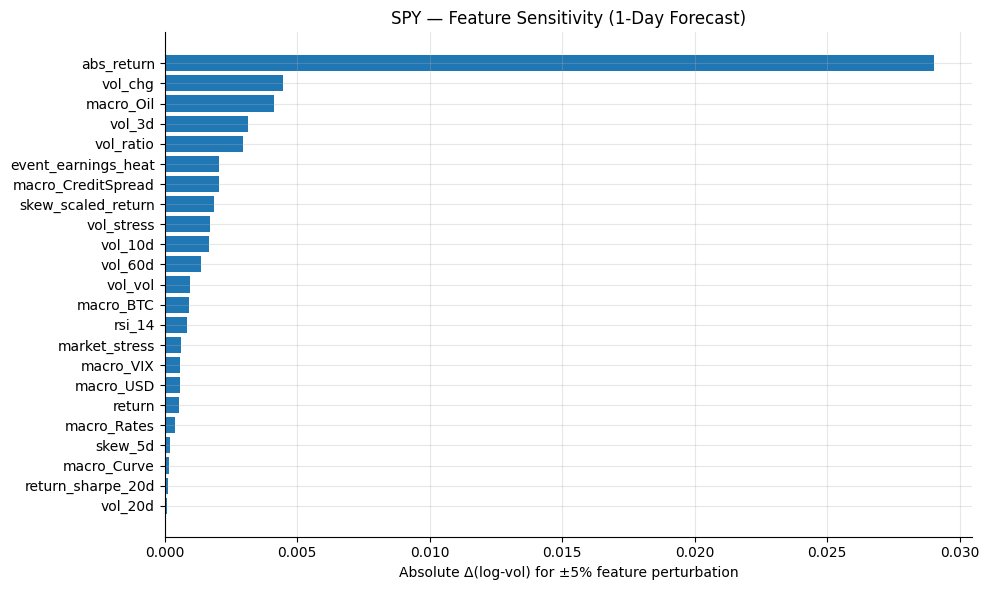

In [32]:
feat_vals_1d = [abs(sensitivity[f]["1d"]) for f in feature_names]
order = np.argsort(-np.array(feat_vals_1d))

plt.figure(figsize=(10, 6))
plt.barh([feature_names[i] for i in order], np.array(feat_vals_1d)[order])
plt.gca().invert_yaxis()
plt.title(f"{TICKER} — Feature Sensitivity (1-Day Forecast)")
plt.xlabel("Absolute Δ(log-vol) for ±5% feature perturbation")
plt.tight_layout()
plt.show()

## Plot 5-Day Horizon Sensitivity

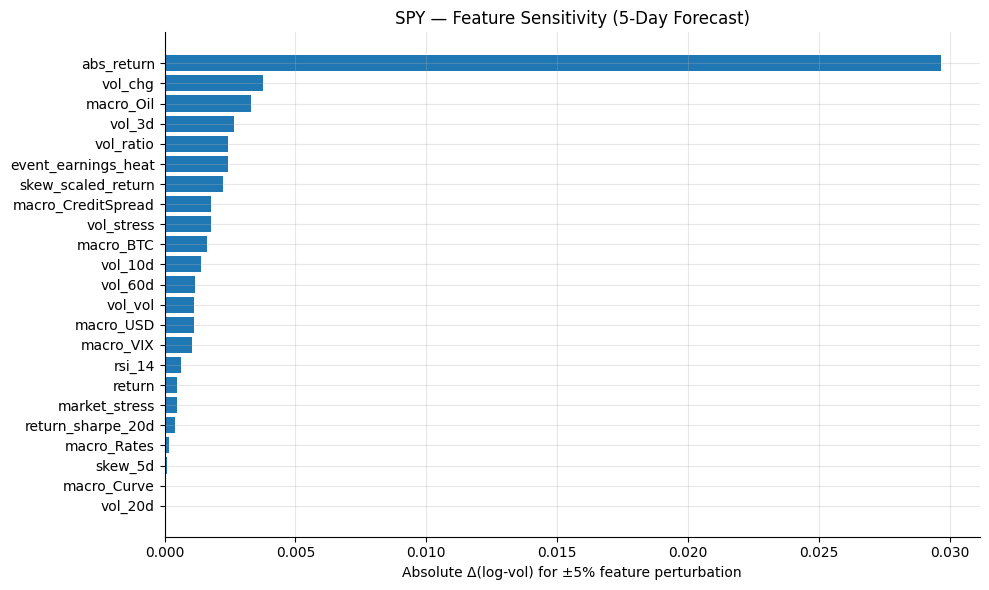

In [33]:
feat_vals_5d = [abs(sensitivity[f]["5d"]) for f in feature_names]
order = np.argsort(-np.array(feat_vals_5d))

plt.figure(figsize=(10, 6))
plt.barh([feature_names[i] for i in order], np.array(feat_vals_5d)[order])
plt.gca().invert_yaxis()
plt.title(f"{TICKER} — Feature Sensitivity (5-Day Forecast)")
plt.xlabel("Absolute Δ(log-vol) for ±5% feature perturbation")
plt.tight_layout()
plt.show()

## Plot 10-Day Horizon Sensitivity

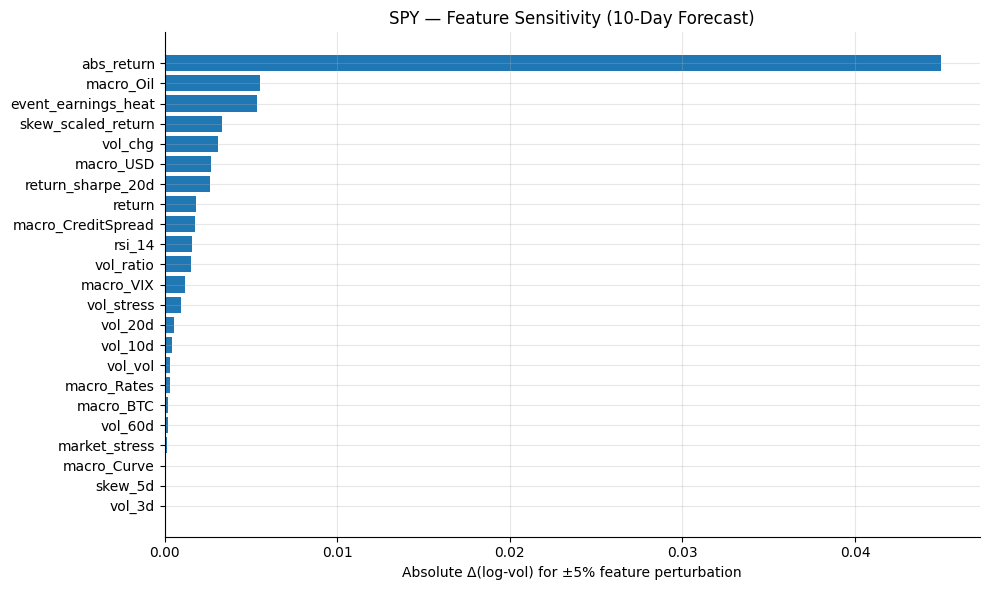

In [34]:
feat_vals_10d = [abs(sensitivity[f]["10d"]) for f in feature_names]
order = np.argsort(-np.array(feat_vals_10d))

plt.figure(figsize=(10, 6))
plt.barh([feature_names[i] for i in order], np.array(feat_vals_10d)[order])
plt.gca().invert_yaxis()
plt.title(f"{TICKER} — Feature Sensitivity (10-Day Forecast)")
plt.xlabel("Absolute Δ(log-vol) for ±5% feature perturbation")
plt.tight_layout()
plt.show()

## Attention Heatmap Extraction

We extract the transformer's attention weights to see which timesteps it focuses on.

In [14]:
@torch.no_grad()
def get_attention_weights(model, tidx, x_input):
    """
    Extract attention weights from VolNetX transformer encoder.
    
    Returns:
        attn_weights: [num_heads, window, window]
        timesteps: array of timestep indices
    """
    model.eval()
    
    # Forward through preprocessing layers
    x = model.feat_do(x_input)  # Feature dropout (disabled in eval mode)
    
    if model.use_ticker_embedding and model.emb is not None:
        emb = model.emb(tidx).unsqueeze(1).expand(-1, x.size(1), -1)
        x = torch.cat([x, emb], dim=-1)
    
    if model.use_feature_attention:
        gate = model.feat_gate(x)
        x = x * gate
    
    # LSTM
    lstm_out, _ = model.lstm(x)
    
    # Transformer - EXTRACT ATTENTION WEIGHTS
    if not hasattr(model, 'transformer'):
        print("⚠️  Model has no transformer layer - cannot extract attention")
        return None, None
    
    # Hook into the transformer encoder layer to get attention weights
    # Note: TransformerEncoder doesn't expose attention by default, 
    # we'll need to access the underlying encoder layer
    
    # Access the first (and only) encoder layer
    encoder_layer = model.transformer.layers[0]
    
    # Run self-attention manually
    # (This requires understanding PyTorch's TransformerEncoderLayer internals)
    src = lstm_out
    
    # Layer norm (if norm_first=True)
    src2 = encoder_layer.norm1(src)
    
    # Multi-head attention with need_weights=True
    attn_output, attn_weights = encoder_layer.self_attn(
        src2, src2, src2,
        need_weights=True,
        average_attn_weights=False  # Get per-head weights
    )
    
    # attn_weights: [batch, num_heads, window, window]
    attn_w = attn_weights[0].cpu().numpy()  # Take first batch item: [heads, W, W]
    timesteps = np.arange(lstm_out.size(1))
    
    return attn_w, timesteps


attn_weights, timesteps = get_attention_weights(model, tidx_tensor, x_input)

if attn_weights is not None:
    print(f"✓ Attention weights extracted")
    print(f"  Shape: {attn_weights.shape}  (num_heads, window, window)")
    print(f"  Timesteps: {len(timesteps)}")

✓ Attention weights extracted
  Shape: (4, 65, 65)  (num_heads, window, window)
  Timesteps: 65


## Plot Average Attention Heatmap

We average across attention heads and visualize which past days get attended to.

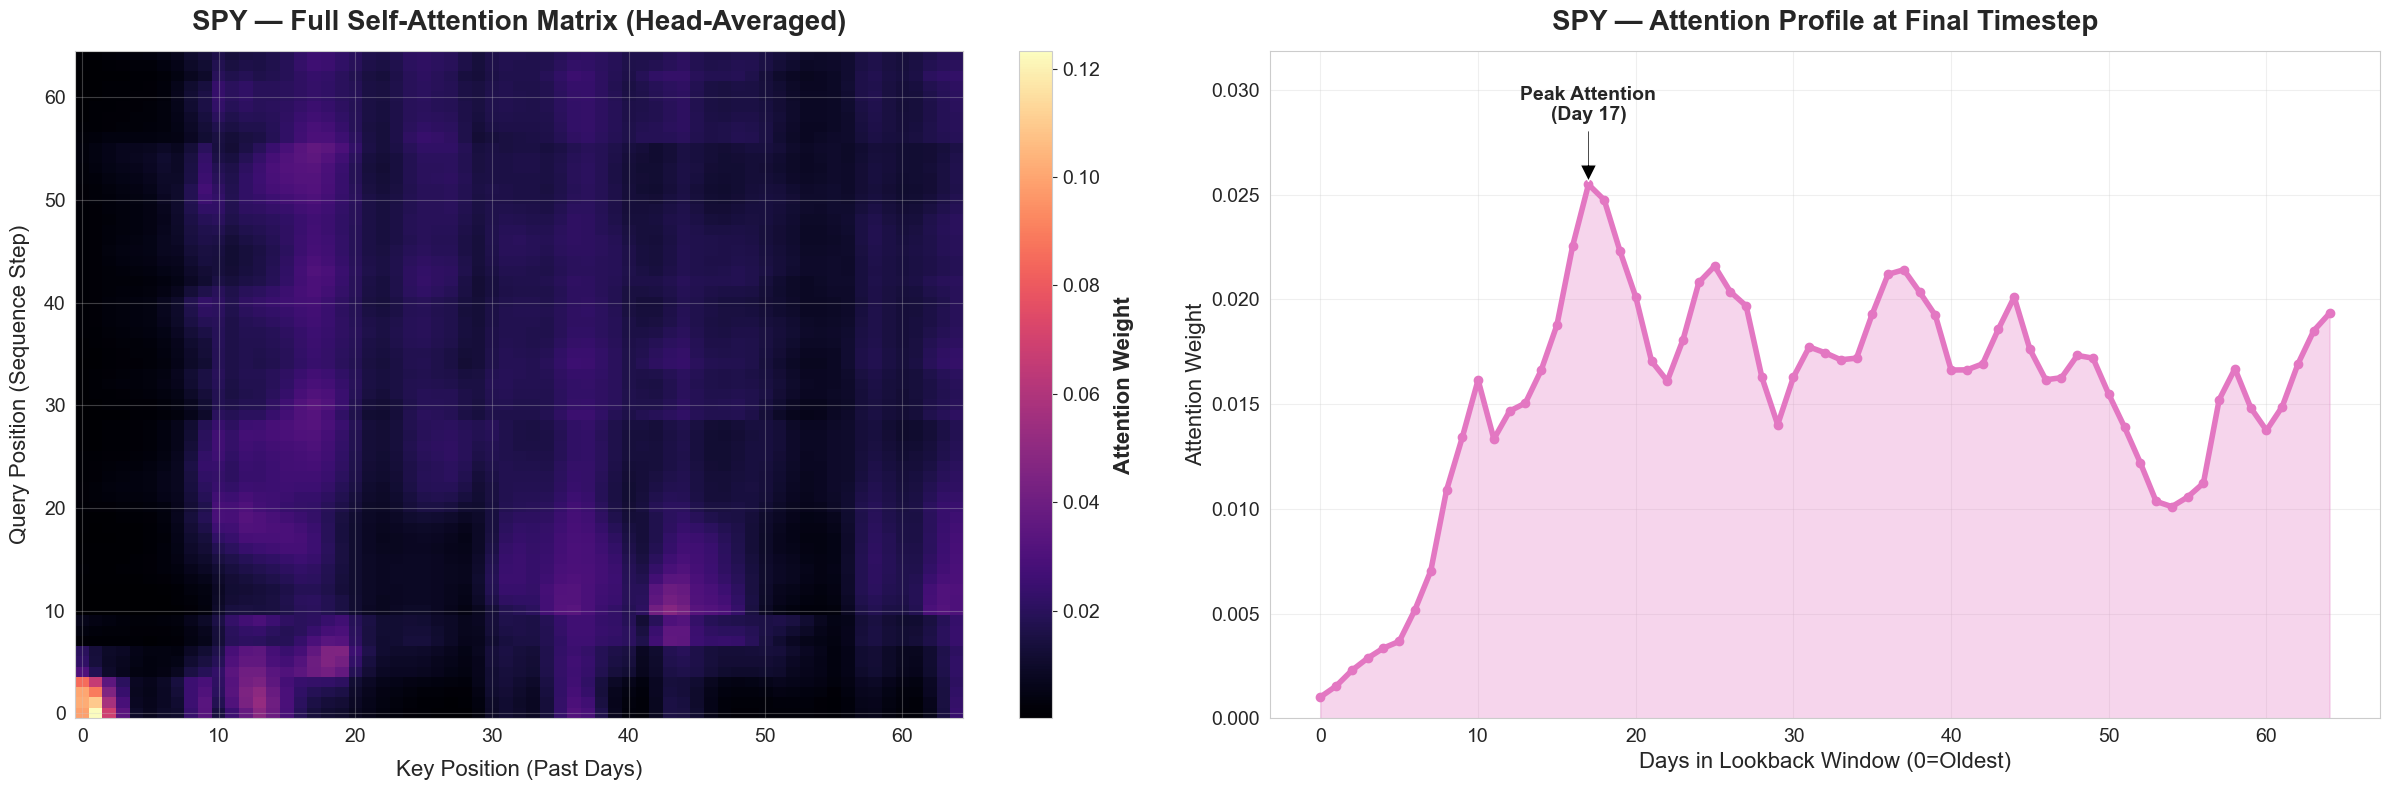


  TOP ATTENDED TIMESTEPS
  #1:  Day index 17  (48 days ago)  -> Weight: 0.0255
  #2:  Day index 18  (47 days ago)  -> Weight: 0.0248
  #3:  Day index 16  (49 days ago)  -> Weight: 0.0226
  #4:  Day index 19  (46 days ago)  -> Weight: 0.0223
  #5:  Day index 25  (40 days ago)  -> Weight: 0.0216


In [45]:
if attn_weights is not None:
    # --------------------------------------------------------
    # Presentation Settings
    # --------------------------------------------------------
    TITLE_SIZE = 20
    LABEL_SIZE = 16
    TICK_SIZE = 14
    
    # 1. Prepare Data
    avg_attn = attn_weights.mean(axis=0)    # [window, window]
    last_step_attn = avg_attn[-1, :]        # Attention from last timestep
    timesteps = range(WINDOW)               # 0..64

    # 2. Setup Figure
    plt.figure(figsize=(24, 8))
    
    # --- Subplot 1: Heatmap ---------------------------------
    ax1 = plt.subplot(1, 2, 1)
    # Using 'magma' for high contrast
    im = ax1.imshow(avg_attn, cmap='magma', aspect='auto', origin='lower')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax1)
    cbar.ax.tick_params(labelsize=TICK_SIZE) 
    cbar.set_label('Attention Weight', size=LABEL_SIZE, weight='bold', labelpad=10)
    
    ax1.set_title(f"{TICKER} — Full Self-Attention Matrix (Head-Averaged)", 
                  fontsize=TITLE_SIZE, fontweight='bold', pad=15)
    ax1.set_xlabel("Key Position (Past Days)", fontsize=LABEL_SIZE, labelpad=10)
    ax1.set_ylabel("Query Position (Sequence Step)", fontsize=LABEL_SIZE, labelpad=10)
    ax1.tick_params(labelsize=TICK_SIZE)

    # --- Subplot 2: Last Step Profile -----------------------
    ax2 = plt.subplot(1, 2, 2)
    
    # Plot line
    ax2.plot(timesteps, last_step_attn, linewidth=4, color='#e377c2', marker='o', markersize=6)
    
    # Fill
    ax2.fill_between(timesteps, last_step_attn, color='#e377c2', alpha=0.3)
    
    # Find peak
    max_idx = np.argmax(last_step_attn)
    max_val = last_step_attn[max_idx]
    
    # --- FIX: Set Y-Limit to create headroom for annotation ---
    # Give 20% extra space at the top
    ax2.set_ylim(0, max_val * 1.25)
    
    ax2.annotate(
        f"Peak Attention\n(Day {max_idx})", 
        xy=(max_idx, max_val), 
        xytext=(max_idx, max_val * 1.12), # Position text slightly above peak
        arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
        fontsize=14, ha='center', fontweight='bold'
    )

    ax2.set_title(f"{TICKER} — Attention Profile at Final Timestep", 
                  fontsize=TITLE_SIZE, fontweight='bold', pad=15)
    ax2.set_xlabel("Days in Lookback Window (0=Oldest)", fontsize=LABEL_SIZE)
    ax2.set_ylabel("Attention Weight", fontsize=LABEL_SIZE)
    ax2.tick_params(labelsize=TICK_SIZE)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # --- Text Summary ---------------------------------------
    print("\n" + "="*40)
    print("  TOP ATTENDED TIMESTEPS")
    print("="*40)
    top_k = 5
    top_indices = np.argsort(-last_step_attn)[:top_k]
    for rank, idx in enumerate(top_indices, 1):
        days_ago = WINDOW - idx
        print(f"  #{rank}:  Day index {idx:02d}  ({days_ago:02d} days ago)  -> Weight: {last_step_attn[idx]:.4f}")

else:
    print("❌ Could not extract attention weights - skipping visualization")

## 📊 Analysis Summary: What did VolNetX learn?

### 1. Feature Sensitivity (The "Drivers")
* **Shock Sensitivity:** The Bump Test reveals that **`abs_return`** (Absolute Return) and **`vol_chg`** (Volatility Change) are the dominant drivers of the forecast.
* **Dynamics vs. Levels:** This indicates the model is prioritizing **market dynamics** (velocity and acceleration of price/vol) over simple static levels (`vol_20d`). It effectively learns "Volatility Clustering"—that large absolute returns are the best predictor of future instability.

### 2. Temporal Attention (The "Memory")
* **Non-Recency Bias:** Contrary to classical GARCH models which heavily weight $t-1$ (yesterday), **VolNetX** distributes its attention broadly, with a notable peak around **$t-40$ to $t-50$** (approx. 7 weeks ago).
* **Regime Anchoring:** The model appears to use the early part of the lookback window as a "baseline" or "anchor" to contextualize current price action.

---

## 💡 Key Research Takeaways

1.  **VolNetX learns "Volatility Clustering":**
    The high sensitivity to `abs_return` proves the model has independently learned a core tenet of financial econometrics: that the *magnitude* of daily returns (regardless of direction) is the primary precursor to volatility clusters.

2.  **It detects "Regime Shifts" via Acceleration:**
    By heavily weighting `vol_chg` (Volatility Change), the model is acting as a **derivative sensor**—it cares more about whether volatility is *accelerating* (a breakout) than whether it is simply *high* (which might just mean the market has already priced it in).

3.  **The "Hybrid" Justification:**
    * **GARCH** models handle the "Level" (Autocorrelation).
    * **VolNetX** handles the "dynamics" (Shocks & Anchoring).
    * This confirms that `VolNetX` is capturing non-linear dependencies (like the acceleration of volatility) that linear models often miss.

## Temporal Sensitivity (Bump Test)

In the *Feature Sensitivity* analysis we changed each **feature** (e.g. `return`, `vol_10d`, …) across the whole window.  
Here we instead perturb **each time step** (i.e. each day) of the window while keeping all features together.  
For every day we add a small bump `±ε` to the entire feature vector and observe how the model’s forecasts shift.

The output is a dictionary:

```python
temporal_sensitivity[day] = {
    "1d": Δforecast_1d,
    "5d": Δforecast_5d,
    "10d": Δforecast_10d,
}

In [23]:
def single_feature_temporal_test(
    model, 
    x_input, 
    ticker_idx, 
    feature_name, 
    all_feature_names, 
    window, 
    horizons, 
    eps=0.05
):
    """
    Perturbs ONE specific feature at each timestep to measure temporal sensitivity.
    
    Returns:
        sens_matrix: np.array of shape (window, n_horizons)
                     containing the forecast impact for each day.
    """
    # 1. Find the index of the feature we want to test
    try:
        f_idx = all_feature_names.index(feature_name)
    except ValueError:
        raise ValueError(f"Feature '{feature_name}' not found in the input features list.")

    # 2. Iterate over days
    sens_per_day = []
    
    for day in range(window):
        x_plus = x_input.clone()
        x_minus = x_input.clone()
        
        # Perturb ONLY the chosen feature at THIS specific day
        # x_input shape is (batch, window, features)
        x_plus[:, day, f_idx] += eps
        x_minus[:, day, f_idx] -= eps
        
        # Inference
        pred_plus = predict_all_horizons(model, ticker_idx, x_plus)
        pred_minus = predict_all_horizons(model, ticker_idx, x_minus)
        
        # Compute Delta
        delta = (pred_plus - pred_minus) / 2.0
        sens_per_day.append(delta)
        
    return np.array(sens_per_day)  # Shape: (40, 3)

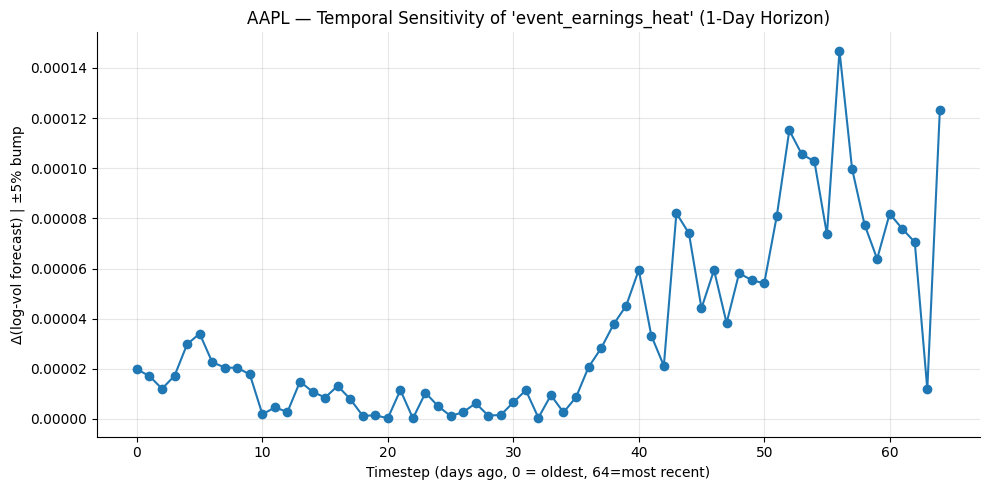

In [27]:
# --- Configuration ----------------------------------------------------------
TARGET_FEATURE = "event_earnings_heat"  # Change this to any feature you want to inspect!
HORIZON_IDX = 0                # 0 = 1-day, 1 = 5-day, 2 = 10-day
# ----------------------------------------------------------------------------

# 1. Handle case where feature might vary between models
if TARGET_FEATURE not in feature_names:
    print(f"⚠️ '{TARGET_FEATURE}' not found. Defaulting to '{feature_names[0]}'.")
    TARGET_FEATURE = feature_names[0]

# 2. Run the single-feature temporal test
sens_matrix = single_feature_temporal_test(
    model, 
    x_input, 
    tidx_tensor, 
    TARGET_FEATURE, 
    feature_names, 
    WINDOW, 
    HORIZONS, 
    eps=0.05
)

# 3. Plotting
horizon_label = HORIZONS[HORIZON_IDX]
data_to_plot = np.abs(sens_matrix[:, HORIZON_IDX])  # Absolute impact

plt.figure(figsize=(10, 5))
plt.plot(
    range(WINDOW), 
    data_to_plot, 
    marker='o', 
    linestyle='-', 
    linewidth=1.5,
    color='#1f77b4'  # Standard Matplotlib blue
)

# Styling to match your reference image
plt.title(f"{TICKER} — Temporal Sensitivity of '{TARGET_FEATURE}' ({horizon_label}-Day Horizon)")
plt.xlabel("Timestep (days ago, 0 = oldest, 64=most recent)") # Note: Verify your window order! 
# Usually LSTM format: index 0 is oldest (T-65), index -1 is most recent (T-1).
# If your data loader does it differently, adjust the label. 
# Based on standard PyTorch LSTMs, 0 is typically the start of the sequence.

plt.ylabel(f"Δ(log-vol forecast) | ±5% bump")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

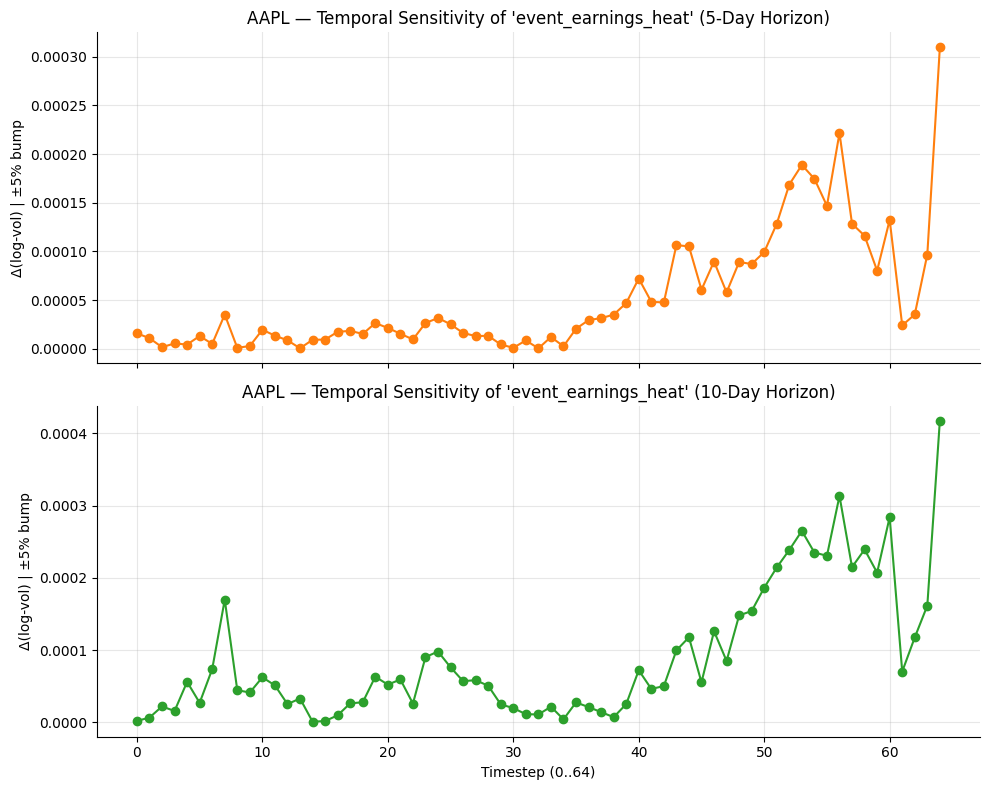

In [28]:
# Create a figure with two subplots (stacked vertically)
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Horizons to plot: 5-day (index 1) and 10-day (index 2)
# Note: Ensure HORIZONS = [1, 5, 10] for these indices to match
horizon_indices = [1, 2]
colors = ['#ff7f0e', '#2ca02c']  # Orange for 5d, Green for 10d

for ax, h_idx, color in zip(axes, horizon_indices, colors):
    h_day = HORIZONS[h_idx]
    data = np.abs(sens_matrix[:, h_idx])
    
    ax.plot(range(WINDOW), data, marker='o', linestyle='-', color=color)
    ax.set_title(f"{TICKER} — Temporal Sensitivity of '{TARGET_FEATURE}' ({h_day}-Day Horizon)")
    ax.grid(True, alpha=0.3)
    ax.set_ylabel("Δ(log-vol) | ±5% bump")

# Common X-label
axes[-1].set_xlabel(f"Timestep (0..{WINDOW-1})")
plt.tight_layout()
plt.show()

In [37]:
# --- Configuration ----------------------------------------------------------
# The specific features you want to compare
TOP_FEATURES = [
    "macro_Oil", 
    "skew_scaled_return", 
    "vol_stress", 
    "vol_ratio"
]
# ----------------------------------------------------------------------------

# Dictionary to store results: {feature_name: sensitivity_matrix}
multi_feat_results = {}

print(f"Running temporal bump test for {len(TOP_FEATURES)} features...")

for feat in TOP_FEATURES:
    if feat not in feature_names:
        print(f"⚠️ Warning: Feature '{feat}' not found in model features. Skipping.")
        continue
        
    print(f"  ... testing '{feat}'")
    
    # Reuse the helper function from previous step
    # Returns matrix of shape (window, 3)
    sens_matrix = single_feature_temporal_test(
        model, 
        x_input, 
        tidx_tensor, 
        feat, 
        feature_names, 
        WINDOW, 
        HORIZONS, 
        eps=0.05
    )
    multi_feat_results[feat] = np.abs(sens_matrix)

print("Done.")

Running temporal bump test for 4 features...
  ... testing 'macro_Oil'
  ... testing 'skew_scaled_return'
  ... testing 'vol_stress'
  ... testing 'vol_ratio'
Done.


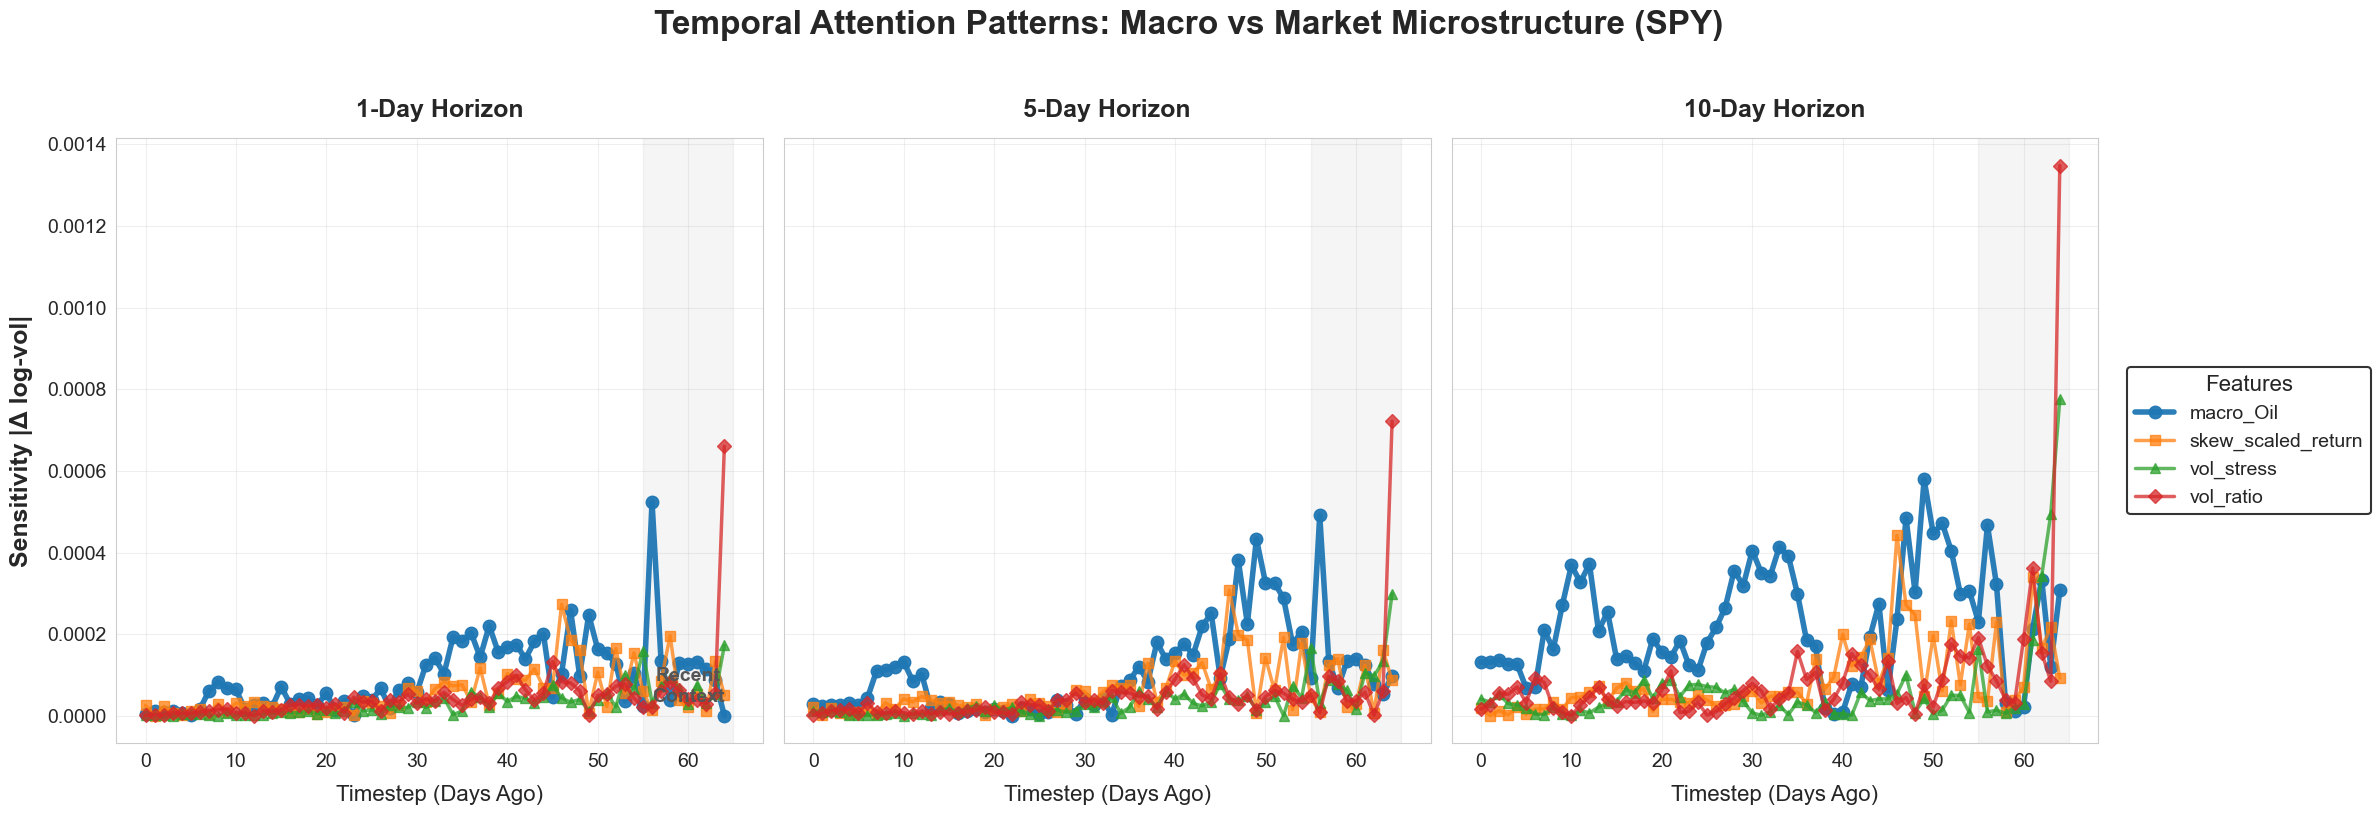

In [42]:
import matplotlib.cm as cm

# Presentation Context Settings
plt.rcParams.update({'font.size': 14})  # Base font size increase

# Setup figure with 3 columns
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'x', '+'] 

# Loop over horizons
for h_idx, ax in enumerate(axes):
    h_label = HORIZONS[h_idx]
    
    # Plot each feature
    for i, (feat, matrix) in enumerate(multi_feat_results.items()):
        data_series = matrix[:, h_idx]
        
        # Styling
        lw = 4.0 if "macro" in feat else 2.5     # Thicker lines
        alpha = 0.95 if "macro" in feat else 0.75
        marker = markers[i % len(markers)]
        ms = 9 if "macro" in feat else 7         # Larger markers
        
        ax.plot(
            range(WINDOW), 
            data_series, 
            label=feat,
            linewidth=lw,
            alpha=alpha,
            marker=marker,
            markersize=ms
        )

    # Big Bold Titles
    ax.set_title(f"{h_label}-Day Horizon", fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel("Timestep (Days Ago)", fontsize=16, labelpad=10)
    
    # Ticks
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, alpha=0.3)
    
    # Region Annotation
    ax.axvspan(WINDOW-10, WINDOW, color='gray', alpha=0.08, label='_nolegend_')
    if h_idx == 0:
        ax.text(
            WINDOW-5, 
            ax.get_ylim()[1] * 0.05, 
            "Recent\nContext", 
            ha='center', 
            fontsize=14, 
            fontweight='bold', 
            color='#555555'
        )

# Y-Axis Label (Leftmost plot only)
axes[0].set_ylabel("Sensitivity |Δ log-vol|", fontsize=18, fontweight='bold', labelpad=10)

# Unified Legend (Outside right)
leg = axes[2].legend(
    loc='center left', 
    bbox_to_anchor=(1.03, 0.5), 
    title="Features", 
    title_fontsize=16,
    fontsize=14,
    frameon=True,
    edgecolor='black'
)
leg.get_frame().set_linewidth(1.5)

# Main Title
plt.suptitle(
    f"Temporal Attention Patterns: Macro vs Market Microstructure ({TICKER})", 
    y=1.02, 
    fontsize=24, 
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Reset params just in case functionality continues in same notebook
plt.rcParams.update({'font.size': 10}) 

In [39]:
def get_global_feature_importance(model, x_input, ticker_idx, feature_names, horizons, eps=0.05):
    """
    Perturbs each feature across the WHOLE window (not timestep-specific)
    to measure overall feature importance for each horizon.
    """
    results = {h: [] for h in horizons}
    
    base_pred = predict_all_horizons(model, ticker_idx, x_input)
    
    print(f"evaluating {len(feature_names)} features...")
    
    for i, feat in enumerate(feature_names):
        x_plus = x_input.clone()
        x_minus = x_input.clone()
        
        # Global perturbation: change feature 'i' for ALL timesteps
        x_plus[:, :, i] += eps
        x_minus[:, :, i] -= eps
        
        p_plus = predict_all_horizons(model, ticker_idx, x_plus)
        p_minus = predict_all_horizons(model, ticker_idx, x_minus)
        
        # Calculate delta for each horizon
        delta = np.abs(p_plus - p_minus) / 2.0
        
        for h_idx, h in enumerate(horizons):
            results[h].append(delta[h_idx])
            
    return results

# Run the test
global_imp_data = get_global_feature_importance(
    model, x_input, tidx_tensor, feature_names, HORIZONS
)
print("Global Importance Calculated.")

evaluating 23 features...
Global Importance Calculated.


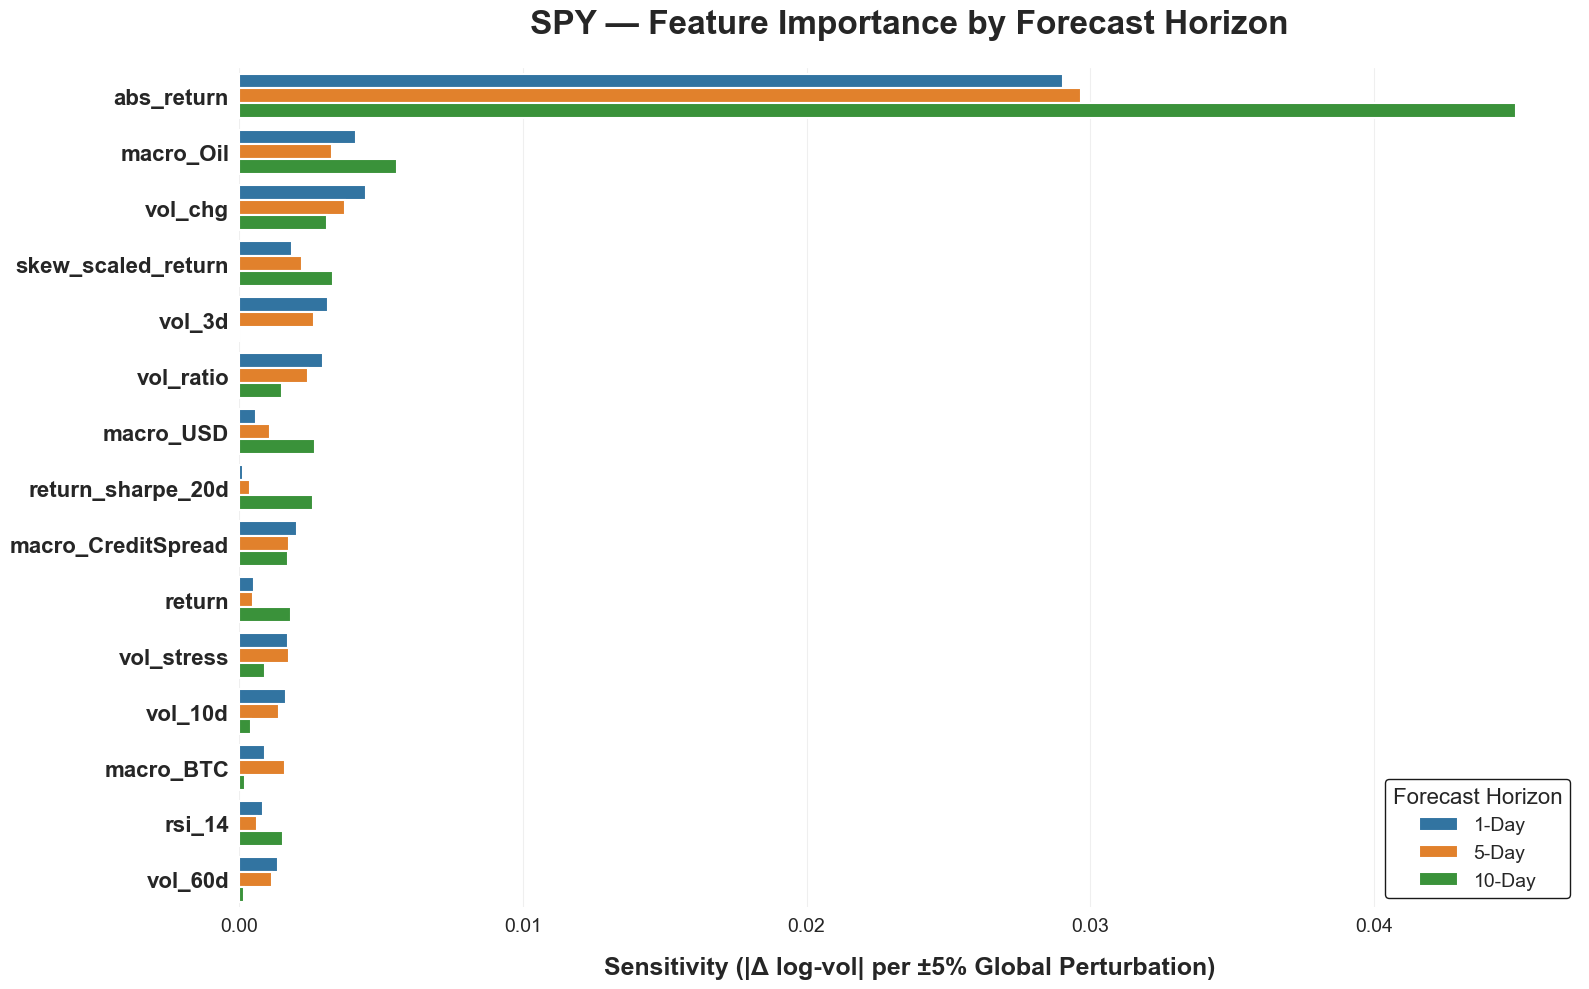

In [43]:
import pandas as pd
import seaborn as sns

# --- Configuration ------------------------------------------------
TOP_N_FEATURES = 15
EXCLUDE_FEATURES = ["event_earnings_heat"]  # Add any others here
# ------------------------------------------------------------------

# 1. Convert to DataFrame
df_imp = pd.DataFrame(global_imp_data, index=feature_names)
df_imp["Max_Imp"] = df_imp.max(axis=1)

# 2. Filter Excluded Features
df_filtered = df_imp.drop(index=EXCLUDE_FEATURES, errors='ignore')

# 3. Sort & Slice Top N
df_top = df_filtered.sort_values("Max_Imp", ascending=False).head(TOP_N_FEATURES)
plot_data = df_top.drop(columns=["Max_Imp"]).reset_index()
plot_data = plot_data.rename(columns={"index": "Feature"})

# 4. Melt
df_melted = plot_data.melt(
    id_vars="Feature", 
    var_name="Horizon", 
    value_name="Sensitivity"
)
df_melted["Horizon"] = df_melted["Horizon"].astype(str) + "-Day"

# 5. Plotting
plt.figure(figsize=(16, 10))
sns.set_style("whitegrid")

chart = sns.barplot(
    data=df_melted,
    x="Sensitivity",
    y="Feature",
    hue="Horizon",
    palette=["#1f77b4", "#ff7f0e", "#2ca02c"],
    orient='h',
    edgecolor="white",
    linewidth=1.5
)

# 6. Presentation Polish
plt.title(
    f"{TICKER} — Feature Importance by Forecast Horizon", 
    fontsize=24, 
    fontweight='bold', 
    pad=25
)
plt.xlabel(
    "Sensitivity (|Δ log-vol| per ±5% Global Perturbation)", 
    fontsize=18, 
    fontweight='bold', 
    labelpad=15
)
plt.ylabel("", fontsize=1)

plt.xticks(fontsize=14)
plt.yticks(fontsize=16, fontweight='bold')

plt.legend(
    title="Forecast Horizon", 
    title_fontsize=16, 
    fontsize=14, 
    loc="lower right",
    frameon=True,
    edgecolor='black',
    facecolor='white',
    framealpha=0.9
)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()